# Pre-Trained Models vgg16

Though it is often necessary to have a large, well annotated dataset to solve a deep learning challenge, there are many  freely available pre-trained models that we can use right out of the box. As you decide to take on your own deep learning project, it is a great idea to start by looking for existing models online that can help you achieve your goal. A great place to explore available models is [NGC](https://ngc.nvidia.com/catalog/models). There are also many models hosted on GitHub that you can find through searching on Google.

## Objectives

* Use TorchVision to load a very well-trained pretrained model
* Preprocess our own images to work with the pretrained model
* Use the pretrained model to perform accurate inference on your own images

In [1]:
import torch
import torchvision.transforms.v2 as transforms
import torchvision.io as tv_io

import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

## An Automated Doggy Door

In this section, we consider the design of an intelligent doggy door capable of allowing dogs to enter and exit while preventing other animals from passing through. Such a system would enable us to keep cats inside the house while ensuring that other animals remain outside.

Using only the techniques discussed so far, implementing this system would require a large and well-annotated dataset containing images of dogs as well as images of other animals. Fortunately, several pre-trained models already exist that have been trained on extremely large image datasets containing a wide variety of animal species.

One of the most influential benchmarks in image classification is the ImageNet Challenge, which has led to the development of numerous state-of-the-art deep learning models. These models have been trained on millions of images and are capable of classifying images into 1000 distinct categories. Many of these categories correspond to different animal species, including multiple breeds of dogs and cats. As a result, such models provide an excellent starting point for implementing the intelligent doggy door system.

[ImageNet challenge](https://en.wikipedia.org/wiki/ImageNet#History_of_the_ImageNet_challenge)

## Loading the Model

We will start by downloading the model. Trained ImageNet models are available to download directly within the TorchVision library. We can see the available models and their details [here](https://pytorch.org/vision/stable/models.html). Any of these models would work for our exercise. We will pick a commonly used one called [VGG16](https://pytorch.org/vision/stable/models/vgg.html) and use the [default weights](https://pytorch.org/vision/stable/models/generated/torchvision.models.vgg19.html#torchvision.models.VGG19_Weights).

In [2]:
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

# load the VGG16 network *pre-trained* on the ImageNet dataset
weights = VGG16_Weights.DEFAULT
model = vgg16(weights=weights)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 60.8MB/s]


Now that it is loaded, let us look at the model. It looks a lot like our convolutional model from the sign language exercise.

In [3]:
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Input dimensions

As with our earlier exercises, our images should match the input dimensions that the model expects. Because PyTorch models are dynamically built, the model itself does not know what its input shape should be. Thankfully, the pretrained `weights` come with their own transforms.

In [4]:
pre_trans = weights.transforms()
pre_trans

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

This is eqiuvalent to the following:

```Python
IMG_WIDTH, IMG_HEIGHT = (224, 224)

pre_trans = transforms.Compose([
    transforms.ToDtype(torch.float32, scale=True), # Converts [0, 255] to [0, 1]
    transforms.Resize((IMG_WIDTH, IMG_HEIGHT)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    transforms.CenterCrop(224)
])
```

One new Transform here is [Normalize](https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html) which will recolor an image based on a provided [mean](https://en.wikipedia.org/wiki/Mean) and [standard deviation](https://en.wikipedia.org/wiki/Standard_deviation). The other new Transform is [CenterCrop](https://pytorch.org/vision/stable/generated/torchvision.transforms.v2.CenterCrop.html#torchvision.transforms.v2.CenterCrop), which removes the edges of the image. We can apply these transforms to any image tensor we'd like to use with the VGG16 model.

## Output dimensions


We observe that the model produces an output vector of size 1000, which corresponds to the number of categories in the ImageNet classification task. This differs from the models used in our previous exercises. In the first exercise, the model produced an output of size 10, corresponding to the ten possible digit classes. In the second exercise, the output dimension was 24, representing the 24 letters of the sign language alphabet that can be captured in a still image.

In contrast, the ImageNet models assign each input image to one of 1000 possible categories. Although the complete ImageNet dataset contains more than 20,000 categories, the widely used benchmark and the associated pre-trained models rely on a subset of 1000 classes. A complete list of these categories can be found here [possible categories here](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a).


Among these categories, a significant portion corresponds to animals, including multiple breeds of dogs and cats. In particular, dog categories correspond to indices 151 through 268, while cat categories correspond to indices 281 through 285. By identifying whether a prediction falls within these ranges, the system can determine the type of animal detected at the door and decide whether access should be granted.

## Loading an Image
We will start by loading in an image and displaying it, as we have done in previous exercises.

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image)

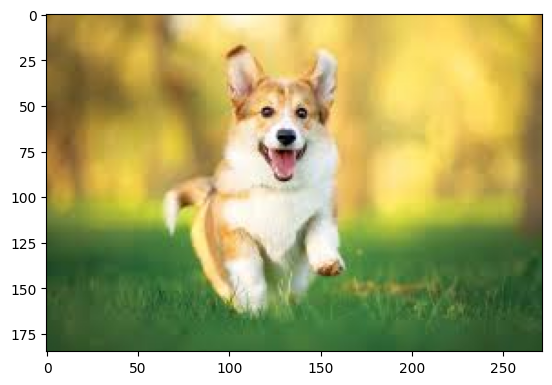

In [9]:
show_image("sample_data/happy_dog.jpg")

## Preprocessing the Image

Next, we will preprocess the image so that it is ready to be sent into the model. This is just like what we did in our last exercise when we predicted on the sign language images. Remember that in this case, the final shape of the image should be (1, 3, 224, 224). We will use the Transforms provided by `weights` to so this.

In [10]:
def load_and_process_image(file_path):
    # Print image's original shape, for reference
    print('Original image shape: ', mpimg.imread(file_path).shape)

    image = tv_io.read_image(file_path).to(device)
    image = pre_trans(image)  # weights.transforms()
    image = image.unsqueeze(0)  # Turn into a batch
    return image

Let's practice on our happy dog photo and see if it worked:

In [12]:
processed_image = load_and_process_image("sample_data/happy_dog.jpg")
print("Processed image shape: ", processed_image.shape)

Original image shape:  (185, 272, 3)
Processed image shape:  torch.Size([1, 3, 224, 224])


The shape is correct, but how does it look? Let's print an image to verify:

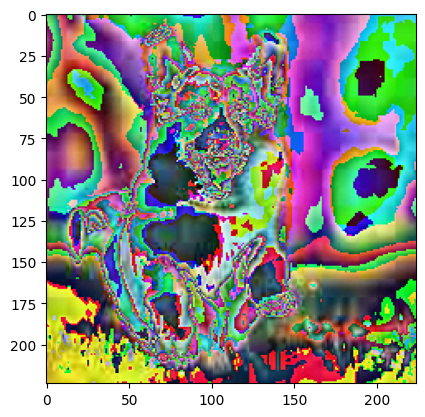

In [13]:
import torchvision.transforms.functional as F

plot_image = F.to_pil_image(torch.squeeze(processed_image))
plt.imshow(plot_image, cmap='gray')

That's a psychadelic effect, but if we squint our eyes, we can still see our happy dog. The strange coloring is due to the `Normalize` Transform, and the photo appears a little zoomed in because of `CenterCrop`.

## Make a Prediction

Now, the image is in the right format, we can pass it into our model and get a prediction. We are expecting an output of an array of 1000 elements, which is going to be difficult to read. We have a list of all the classes in [json](https://www.json.org/json-en.html) format, which is similar to a combination of python lists and dictionaries. In fact, let's load it into a combination of lists and dictionaries.

NOTE: The original notebook assumes a file "data/imagenet_class_index.json" exists with the mapping of indices to ImageNet class names. Since we don't have that file, we generate it directly from torchvision using the VGG16 model's own metadata.This ensures the class names match exactly with the model's predictions.

In [24]:
categories = VGG16_Weights.DEFAULT.meta["categories"]
vgg_classes = {str(i): [f"n{i:08d}", name] for i, name in enumerate(categories)}
print("Total classes:", len(vgg_classes))
print("Example clase 151:", vgg_classes["151"])

Total classes: 1000
Example clase 151: ['n00000151', 'Chihuahua']


In [25]:
vgg_classes["0"]

['n00000000', 'tench']

Let's create a function to make a prediction from the VGG model human readable. This is similar to our `predict_letter` function from the previous lesson. This time, we will use the [torch.topk](https://pytorch.org/docs/stable/generated/torch.topk.html) function to give us the top `3` predictions.

In [26]:
def readable_prediction(image_path):
    # Show image
    show_image(image_path)
    # Load and pre-process image
    image = load_and_process_image(image_path)
    # Make predictions
    output = model(image)[0]  # Unbatch
    predictions = torch.topk(output, 3)
    indices = predictions.indices.tolist()
    # Print predictions in readable form
    out_str = "Top results: "
    pred_classes = [vgg_classes[str(idx)][1] for idx in indices]
    out_str += ", ".join(pred_classes)
    print(out_str)

    return predictions

Try it out on a few animals to see the results! Also feel free to upload your own images and categorize them just to see how well it works.

Original image shape:  (185, 272, 3)
Top results: Pembroke, Cardigan, basenji


torch.return_types.topk(
values=tensor([18.0172, 17.8680, 14.4910], grad_fn=<TopkBackward0>),
indices=tensor([263, 264, 253]))

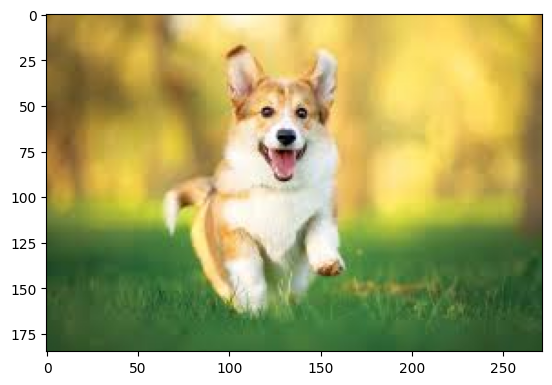

In [28]:
readable_prediction("sample_data/happy_dog.jpg")

Original image shape:  (360, 540, 3)
Top results: tiger cat, computer keyboard, tabby


torch.return_types.topk(
values=tensor([10.2204,  9.3728,  8.6788], grad_fn=<TopkBackward0>),
indices=tensor([282, 508, 281]))

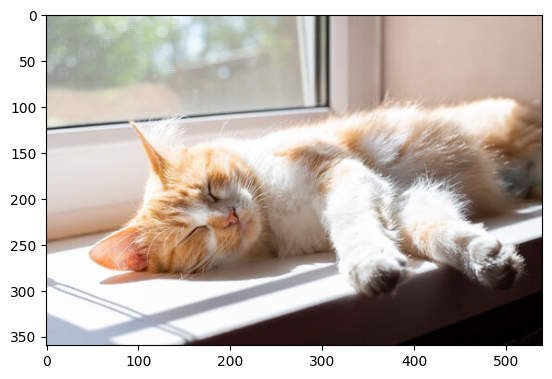

In [30]:
readable_prediction("sample_data/sleepy_cat.jpg")

## Only Dogs

Now that we are making predictions with our model, we can use our categories to only let dogs in and out and keep cats inside. The dogs are categories 151 through 268 and cats are categories 281 through 285.

In [31]:
import numpy as np

def doggy_door(image_path):
    show_image(image_path)
    image = load_and_process_image(image_path)
    idx = model(image).argmax(dim=1).item()
    print("Predicted index:", idx)
    if 151 <= idx <= 268:
        print("Doggy come on in!")
    elif 281 <= idx <= 285:
        print("Kitty stay inside!")
    else:
        print("You're not a dog! Stay outside!")

Original image shape:  (185, 272, 3)
Predicted index: 263
Doggy come on in!


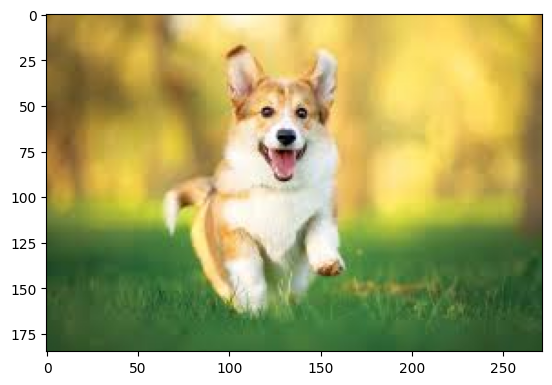

In [33]:
doggy_door("sample_data/happy_dog.jpg")

Original image shape:  (360, 540, 3)
Predicted index: 282
Kitty stay inside!


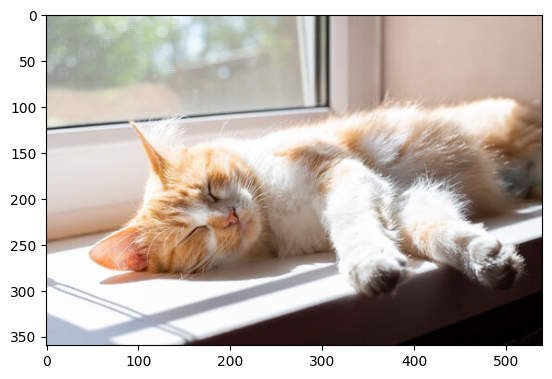

In [34]:
doggy_door("sample_data/sleepy_cat.jpg")

## Summary

Great work! Using a powerful pre-trained model, we have created a functional doggy door in just a few lines of code. We hope you are excited to take advantage of deep learning without a lot of up-front work. The best part is, as the deep learning community moves forward, more models will become available for you to use on your own projects.

### Clear the Memory
Before moving on, please execute the following cell to clear up the GPU memory.

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

## Next

Using pretrained models is incredibly powerful, but sometimes they are not a perfect fit for your data. In the next section you will learn about another powerful technique, *transfer learning*, which allows you to tailer pretrained models to make good predictions for your data.

Continue to the next section: [*Pretrained Models*](./05b_presidential_doggy_door.ipynb).

<center><a href="https://www.nvidia.com/dli"> <img src="images/DLI_Header.png" alt="Header" style="width: 400px;"/> </a></center>